In [30]:
from pathlib import Path
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [31]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

documents = {}

for file in DATA_DIR.glob("*.txt"):
    documents[file.stem] = file.read_text(encoding="utf-8")

print(f"Loaded {len(documents)} documents.")

Loaded 10 documents.


In [32]:
def clean_text(text):
    text = text.lower()
    
    # Remove page number markers like "p. 31"
    text = re.sub(r'\bp\.\s*\d+\b', ' ', text)
    
    # Remove standalone punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Fix common OCR join artefacts (optional)
    text = text.replace("ofthe", "of the")
    
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

cleaned_docs = {k: clean_text(v) for k, v in documents.items()}

# Corpus Level Word Frequency

In [33]:
all_words = " ".join(cleaned_docs.values()).split()
freq = Counter(all_words)

freq.most_common(20)

[('the', 2871),
 ('of', 2058),
 ('and', 1468),
 ('in', 1026),
 ('to', 988),
 ('a', 980),
 ('is', 718),
 ('that', 487),
 ('s', 474),
 ('as', 426),
 ('it', 345),
 ('this', 289),
 ('from', 272),
 ('for', 271),
 ('with', 258),
 ('by', 247),
 ('carpentaria', 246),
 ('an', 236),
 ('on', 218),
 ('wright', 215)]

In [34]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Step 1: remove stopwords
filtered_words = [
    w for w in all_words 
    if w not in ENGLISH_STOP_WORDS
]

# Step 2: remove anchors + artefacts together
remove_terms = {'carpentaria', 'wright', 'alexis', 's'}

noise_terms = {
    'functionality', 'licensors', 'warranties', 'cengage',
    'gale', 'machine', 'generated', 'pdf',
    'copyright', 'reproduced', 'permission',
    'vol', 'issue', 'page', 'pp', 'p',
    'feb', 'february',
    'informit', 'timrofni', 'ylrehtuos',
    'eht', 'fo'
}

exclusion_terms = remove_terms.union(noise_terms)

filtered_words = [
    w for w in filtered_words
    if len(w) > 2 and w not in exclusion_terms
]

from collections import Counter
Counter(filtered_words).most_common(20)

[('indigenous', 135),
 ('white', 123),
 ('magic', 123),
 ('novel', 117),
 ('realism', 104),
 ('nation', 102),
 ('place', 100),
 ('world', 81),
 ('aboriginal', 79),
 ('people', 77),
 ('new', 66),
 ('australian', 65),
 ('like', 63),
 ('dreamhunter', 63),
 ('land', 62),
 ('country', 62),
 ('time', 61),
 ('story', 61),
 ('magical', 59),
 ('reality', 59)]

Visualise the most common words

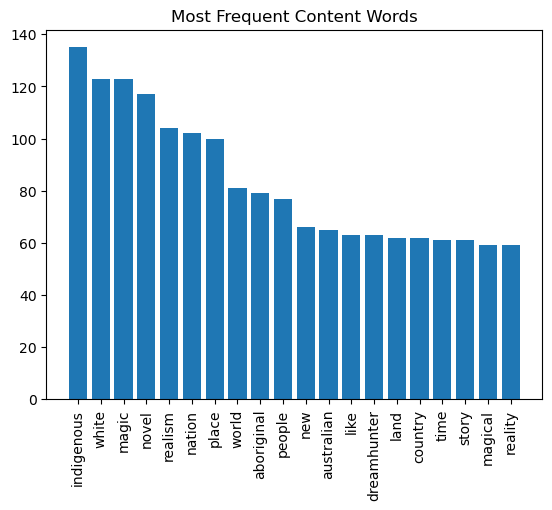

In [35]:
common = Counter(filtered_words).most_common(20)
words, counts = zip(*common)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Most Frequent Content Words")
plt.show()

# TF-IDF Analysis
TF-IDF stands for Term Frequency–Inverse Document Frequency. It is a statistical measure used in text analysis to identify words that are important within a document relative to a corpus.
It does not measure absolute importance. It measures distinctiveness.
TF-IDF is identifying terms that are:
Relatively frequent in one document
Relatively rare in the rest of the corpus
So these lists represent what distinguishes each text from the others.

In [36]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

tfidf_matrix = vectorizer.fit_transform(cleaned_docs.values())
feature_names = vectorizer.get_feature_names_out()

Top terms in each document

In [37]:
for i, doc_name in enumerate(cleaned_docs.keys()):
    row = tfidf_matrix[i].toarray()[0]
    top_indices = np.argsort(row)[-10:]
    top_terms = [feature_names[j] for j in top_indices]
    print(doc_name)
    print(top_terms)
    print()

2008-01-01__shoemaker-a__hecate__hard-dreams-and-indigenous-worlds-in-australias-north__journal-article
['brien', 'howard', 'fear', 'federal', 'hecate', 'australia', 'minister', 'prime', 'wright', 'indigenous']

2009-03-01__no-author__kirkus-reviews__wright-alexis-carpentaria__book-review
['functionality', 'licensors', 'warranties', 'wright', 'cengage', 'kirkus', 'gale', 'machine', 'generated', 'pdf']

2007__perlez-jane__new-york-times-book-review__aboriginal-lit-alexis-wright-carpentaria__book-review
['feature', 'feb', 'february', 'federal', 'feel', 'fat', 'zone', 'copyright', 'reproduced', 'permission']

2008-01-01__devlin-glass-frances__australian-literary-studies__a-politics-of-the-dreamtime-destructive-and-regenerative-rainbows-in-alexis-wrights-carpentaria__journal-article
['dreamtime', 'indigenous', 'sacred', 'bradley', 'wright', 'rainbow', 'sea', 'waanyi', 'norm', 'yanyuwa']

2009-01-01__joseph-laura__southerly__opening-the-gates-of-hell-regional-emergences-in-carpentaria-and-d

Some meaningful stylistic signals thus far:
1. Devlin-Glass (Australian Literary Studies) ['dreamtime', 'indigenous', 'sacred', 
 'bradley', 'rainbow', 'waanyi', 'norm', 'yanyuwa']
strong evidence of:
- Indigenous cosmology focus
- Sacred geography
- Specific cultural referents

2. Ravenscroft (Cultural Studies Review) ['law', 'critics', 'realism', 'reality', 'white', 'magic']
suggests:
- Theoretical framing
- racialised reading?
- Magical realism framing

3. Shoemaker (Hecate) ['howard', 'federal', 'minister', 'prime']
suggests:
- Political-national framing
- Engagement with contemporary politics

4. Sharrad (Conference presentation) ['derrida', 'white', 'land', 'aboriginal', 'writing', 'plains', 'carpentaria', 'language', 'wright', 'promise']
suggests:
- Derrida?



In [39]:
# BUILD BIGRAM FREQUENCIES CORPUS WIDE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import pandas as pd

# Combine all documents into one corpus list
corpus = list(cleaned_docs.values())

# Combine standard stopwords with your exclusions
combined_stopwords = set(ENGLISH_STOP_WORDS).union(exclusion_terms)

vectorizer = CountVectorizer(
    stop_words=list(combined_stopwords),
    ngram_range=(2, 2),
    token_pattern=r"(?u)\b[a-z]{3,}\b",
    min_df=2
)

X = vectorizer.fit_transform(corpus)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

bigram_freq = pd.DataFrame({
    "bigram": bigrams,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

bigram_freq.head(20)

,bigram,count
392,magic realism,51
148,devlin glass,47
650,tsea enruoblem,25
265,gro hcraes,25
277,hcraes morf,25
125,ctu tsea,25
722,ytisrevinu iod,25
202,enruoblem ytisrevinu,25
320,iod gro,25
424,morf dedaolnwod,25


In [41]:
#COMPARE BIGRAMS BY GENRE
from collections import defaultdict

doc_type = {name: name.split("__")[-1] for name in cleaned_docs.keys()}

for t in set(doc_type.values()):
    group_texts = [
        cleaned_docs[name]
        for name in cleaned_docs
        if doc_type[name] == t
    ]
    
    if len(group_texts) < 2:
        continue
    
    vectorizer = CountVectorizer(
        stop_words=list(combined_stopwords),
        ngram_range=(2, 2),
        token_pattern=r"(?u)\b[a-z]{3,}\b",
        min_df=1
    )
    
    X = vectorizer.fit_transform(group_texts)
    counts = X.sum(axis=0).A1
    bigrams = vectorizer.get_feature_names_out()
    
    df = pd.DataFrame({
        "bigram": bigrams,
        "count": counts
    }).sort_values(by="count", ascending=False)
    
    print(f"\n=== {t} ===")
    print(df.head(15))


=== book-review ===
                      bigram  count
11          academic onefile      4
179           conceived tram      3
517  limitation availability      2
830         selected content      2
820         scanned learning      2
239      disclaimer selected      2
238         disclaim express      2
617         non infringement      2
107              book review      2
110            bookmark aone      2
247                 doc aone      2
935  timeliness completeness      2
452         intended replace      2
362             forgo claims      2
626           normal phantom      2

=== journal-article ===
                     bigram  count
7702          magic realism     50
3080           devlin glass     41
4057   enruoblem ytisrevinu     25
13499        tsea enruoblem     25
5451             gro hcraes     25
14591        ytisrevinu iod     25
5638            hcraes morf     25
2582               ctu tsea     25
6634                iod gro     25
8349        morf dedaolnwod 

corpus already indicates that:
magical realism is a major reception frame across genres.
Scholarly criticism tends to produce collocations linking politics and cosmology (for example politics dreamtime, rainbow serpent).
There is a visible reception vocabulary around whiteness (white reader) and place (gulf country).